**Imports**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Generated Dummy Data**

In [2]:
np.random.seed(42)

n_samples = 500
true_w, true_b = 3.5, 7.0          # asal weight/bias jo hum recover karna chahte hain

X = np.random.rand(n_samples, 1) * 10          # X values 0-10 ke beech
noise = np.random.randn(n_samples, 1) * 1.5     # thora sa random noise
y = true_w * X + true_b + noise                 # y = 3.5x + 7 + noise

print(f"Dummy data ready: {n_samples} samples")
print(f"True parameters -> w = {true_w}, b = {true_b}")

# Dekh lein data ka preview
df = pd.DataFrame({'X': X.flatten(), 'y': y.flatten()})
df.head(10)

Dummy data ready: 500 samples
True parameters -> w = 3.5, b = 7.0


,X,y
0,3.745401,20.621538
1,9.507143,43.089257
2,7.319939,34.045424
3,5.986585,27.087691
4,1.560186,11.113030
5,1.559945,13.197687
6,0.580836,7.052577
7,8.661761,40.063353
8,6.011150,29.808186
9,7.080726,31.078777


**Loss and Gradient Functions**

In [3]:
def compute_loss(X, y, w, b):
    y_pred = w * X + b
    return np.mean((y_pred - y) ** 2)


def compute_gradients(X_batch, y_batch, w, b):
    n = len(X_batch)
    y_pred = w * X_batch + b
    error = y_pred - y_batch
    dw = (2 / n) * np.sum(error * X_batch)
    db = (2 / n) * np.sum(error)
    return dw, db

** Batch Gradient Descent**

In [4]:
def batch_gradient_descent(X, y, lr=0.01, epochs=100):
    w, b = 0.0, 0.0
    losses = []
    for epoch in range(epochs):
        dw, db = compute_gradients(X, y, w, b)
        w -= lr * dw
        b -= lr * db
        losses.append(compute_loss(X, y, w, b))
    return w, b, losses

**Stochastic Gradient Descent (SGD)**

In [5]:
def stochastic_gradient_descent(X, y, lr=0.01, epochs=100):
    w, b = 0.0, 0.0
    losses = []
    n = len(X)
    for epoch in range(epochs):
        indices = np.random.permutation(n)   # data shuffle har epoch
        for i in indices:
            X_i = X[i:i+1]
            y_i = y[i:i+1]
            dw, db = compute_gradients(X_i, y_i, w, b)
            w -= lr * dw
            b -= lr * db
        losses.append(compute_loss(X, y, w, b))   # epoch ke end pe pure data ka loss
    return w, b, losses

**Mini-batch Gradient Descent**

In [6]:
def minibatch_gradient_descent(X, y, lr=0.01, epochs=100, batch_size=32):
    w, b = 0.0, 0.0
    losses = []
    n = len(X)
    for epoch in range(epochs):
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            dw, db = compute_gradients(X_batch, y_batch, w, b)
            w -= lr * dw
            b -= lr * db
        losses.append(compute_loss(X, y, w, b))
    return w, b, losses

** Adam Optimizer**

In [7]:
def adam_optimizer(X, y, lr=0.01, epochs=100, batch_size=32,
                    beta1=0.9, beta2=0.999, eps=1e-8):
    w, b = 0.0, 0.0
    m_w, v_w = 0.0, 0.0     # w ke liye moment estimates
    m_b, v_b = 0.0, 0.0     # b ke liye moment estimates
    losses = []
    n = len(X)
    t = 0   # timestep counter (bias correction ke liye)

    for epoch in range(epochs):
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for start in range(0, n, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]

            dw, db = compute_gradients(X_batch, y_batch, w, b)
            t += 1

            # Momentum update (1st moment)
            m_w = beta1 * m_w + (1 - beta1) * dw
            m_b = beta1 * m_b + (1 - beta1) * db

            # RMSProp-style update (2nd moment)
            v_w = beta2 * v_w + (1 - beta2) * (dw ** 2)
            v_b = beta2 * v_b + (1 - beta2) * (db ** 2)

            # Bias correction
            m_w_hat = m_w / (1 - beta1 ** t)
            m_b_hat = m_b / (1 - beta1 ** t)
            v_w_hat = v_w / (1 - beta2 ** t)
            v_b_hat = v_b / (1 - beta2 ** t)

            # Parameter update
            w -= lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
            b -= lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

        losses.append(compute_loss(X, y, w, b))
    return w, b, losses

**Run all techniques**

In [10]:
EPOCHS = 300   # 100 se 300 kar diya
LR = 0.01

w_bgd, b_bgd, loss_bgd = batch_gradient_descent(X, y, lr=LR, epochs=EPOCHS)
w_sgd, b_sgd, loss_sgd = stochastic_gradient_descent(X, y, lr=LR, epochs=EPOCHS)
w_mbgd, b_mbgd, loss_mbgd = minibatch_gradient_descent(X, y, lr=LR, epochs=EPOCHS, batch_size=32)
w_adam, b_adam, loss_adam = adam_optimizer(X, y, lr=LR, epochs=EPOCHS, batch_size=32)

print("--- Final Learned Parameters ---")
print(f"Batch GD      -> w = {w_bgd:.4f}, b = {b_bgd:.4f}, final loss = {loss_bgd[-1]:.4f}")
print(f"SGD           -> w = {w_sgd:.4f}, b = {b_sgd:.4f}, final loss = {loss_sgd[-1]:.4f}")
print(f"Mini-batch GD -> w = {w_mbgd:.4f}, b = {b_mbgd:.4f}, final loss = {loss_mbgd[-1]:.4f}")
print(f"Adam          -> w = {w_adam:.4f}, b = {b_adam:.4f}, final loss = {loss_adam[-1]:.4f}")

--- Final Learned Parameters ---
Batch GD      -> w = 3.7291, b = 5.5316, final loss = 2.7179
SGD           -> w = 3.7497, b = 7.0917, final loss = 4.4344
Mini-batch GD -> w = 3.5430, b = 6.8415, final loss = 2.2694
Adam          -> w = 3.5410, b = 6.7871, final loss = 2.2675


**Comparison Plot**

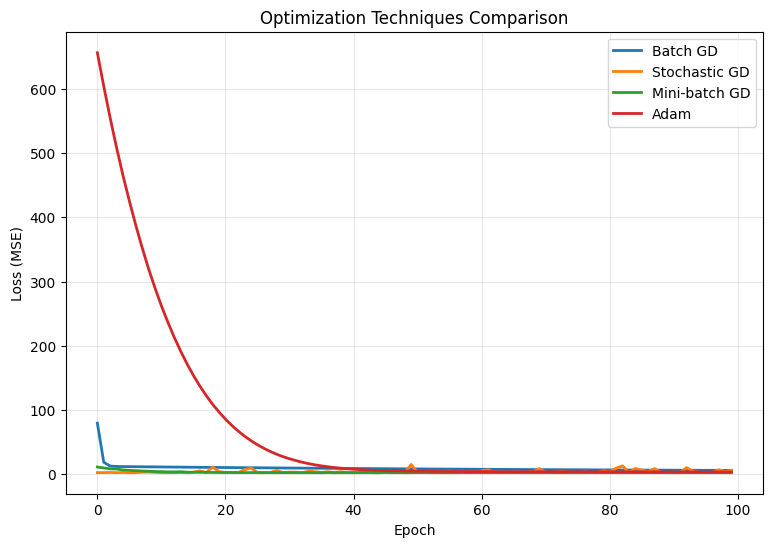

In [9]:
plt.figure(figsize=(9, 6))
plt.plot(loss_bgd, label="Batch GD", linewidth=2)
plt.plot(loss_sgd, label="Stochastic GD", linewidth=2)
plt.plot(loss_mbgd, label="Mini-batch GD", linewidth=2)
plt.plot(loss_adam, label="Adam", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Optimization Techniques Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()